# **Import Libraries**

In [156]:
# =====================================================
# Import Required Libraries
# =====================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Google Colab Prediction System
import ipywidgets as widgets
from IPython.display import display, clear_output

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("="*60)
print("All Required Libraries Imported Successfully")
print("="*60)

# **Dataset Loading**

In [ ]:
from google.colab import files
uploaded = files.upload()

In [157]:
customer_churn = pd.read_csv("telecom_customer_churn.csv")

In [158]:
pd.set_option('display.max_columns', None)
customer_churn.head(30)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
5,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,9,Offer E,Yes,16.77,No,Yes,Cable,73.0,No,No,No,Yes,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Credit Card,69.40,571.45,0.00,0,150.93,722.38,Stayed,NaN,NaN
6,0013-SMEOE,Female,67,Yes,0,Lompoc,93437,34.757477,-120.550507,1,71,Offer A,Yes,9.96,No,Yes,Fiber Optic,14.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,Yes,Bank Withdrawal,109.70,7904.25,0.00,0,707.16,8611.41,Stayed,NaN,NaN
7,0014-BMAQU,Male,52,Yes,0,Napa,94558,38.489789,-122.270110,8,63,Offer B,Yes,12.96,Yes,Yes,Fiber Optic,7.0,Yes,No,No,Yes,No,No,No,No,Two Year,Yes,Credit Card,84.65,5377.80,0.00,20,816.48,6214.28,Stayed,NaN,NaN
8,0015-UOCOJ,Female,68,No,0,Simi Valley,93063,34.296813,-118.685703,0,7,Offer E,Yes,10.53,No,Yes,DSL,21.0,Yes,No,No,No,No,No,No,Yes,Two Year,Yes,Bank Withdrawal,48.20,340.35,0.00,0,73.71,414.06,Stayed,NaN,NaN
9,0016-QLJIS,Female,43,Yes,1,Sheridan,95681,38.984756,-121.345074,3,65,NaN,Yes,28.46,Yes,Yes,Cable,14.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,Yes,Credit Card,90.45,5957.90,0.00,0,1849.90,7807.80,Stayed,NaN,NaN


#**Check dataset Shape**

In [159]:
customer_churn.shape

(7043, 38)

# **Dataset information**

In [160]:
customer_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

# **Checking the missing values**

In [161]:
customer_churn.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Zip Code,0
Latitude,0
Longitude,0
Number of Referrals,0


# **Use Median and Mode for fill the coloums and manage the missing values**

In [162]:
# Fill numerical columns with Median
customer_churn["Avg Monthly Long Distance Charges"].fillna(
    customer_churn["Avg Monthly Long Distance Charges"].median(),
    inplace=True
)

customer_churn["Avg Monthly GB Download"].fillna(
    customer_churn["Avg Monthly GB Download"].median(),
    inplace=True
)

# Fill categorical columns with Mode
categorical_columns = [
    "Offer",
    "Multiple Lines",
    "Internet Type",
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Unlimited Data"
]

for col in categorical_columns:
    customer_churn[col].fillna(customer_churn[col].mode()[0], inplace=True)

# Fill missing values in Churn Category using existing values
customer_churn.loc[customer_churn["Churn Category"].isna(), "Churn Category"] = np.random.choice(
    customer_churn["Churn Category"].dropna(),
    size=customer_churn["Churn Category"].isna().sum(),
    replace=True
)

# Fill missing values in Churn Reason using existing values
customer_churn.loc[customer_churn["Churn Reason"].isna(), "Churn Reason"] = np.random.choice(
    customer_churn["Churn Reason"].dropna(),
    size=customer_churn["Churn Reason"].isna().sum(),
    replace=True
)


/tmp/ipykernel_2220/2815946721.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_2220/2815946721.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

# **Print again after Hendal the missing values**

In [163]:
customer_churn.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Zip Code,0
Latitude,0
Longitude,0
Number of Referrals,0


In [164]:
pd.set_option('display.max_columns', None)
customer_churn.head(30)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,Offer B,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,Competitor,Competitor made better offer
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,Offer B,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,Other,Competitor had better devices
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,Offer B,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
5,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,9,Offer E,Yes,16.77,No,Yes,Cable,73.0,No,No,No,Yes,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Credit Card,69.40,571.45,0.00,0,150.93,722.38,Stayed,Competitor,Long distance charges
6,0013-SMEOE,Female,67,Yes,0,Lompoc,93437,34.757477,-120.550507,1,71,Offer A,Yes,9.96,No,Yes,Fiber Optic,14.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,Yes,Bank Withdrawal,109.70,7904.25,0.00,0,707.16,8611.41,Stayed,Dissatisfaction,Competitor made better offer
7,0014-BMAQU,Male,52,Yes,0,Napa,94558,38.489789,-122.270110,8,63,Offer B,Yes,12.96,Yes,Yes,Fiber Optic,7.0,Yes,No,No,Yes,No,No,No,No,Two Year,Yes,Credit Card,84.65,5377.80,0.00,20,816.48,6214.28,Stayed,Competitor,Competitor offered higher download speeds
8,0015-UOCOJ,Female,68,No,0,Simi Valley,93063,34.296813,-118.685703,0,7,Offer E,Yes,10.53,No,Yes,DSL,21.0,Yes,No,No,No,No,No,No,Yes,Two Year,Yes,Bank Withdrawal,48.20,340.35,0.00,0,73.71,414.06,Stayed,Competitor,Competitor made better offer
9,0016-QLJIS,Female,43,Yes,1,Sheridan,95681,38.984756,-121.345074,3,65,Offer B,Yes,28.46,Yes,Yes,Cable,14.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,Yes,Credit Card,90.45,5957.90,0.00,0,1849.90,7807.80,Stayed,Competitor,Competitor made better offer


# **Check for Duplicate Records**

In [165]:
customer_churn.duplicated().sum()

np.int64(0)

# **Summary statistics**

In [166]:
customer_churn.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.446612,25.065455,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,13.495466,17.466342,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,14.455000,15.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,36.395000,27.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


# **Customer Status Distribution**

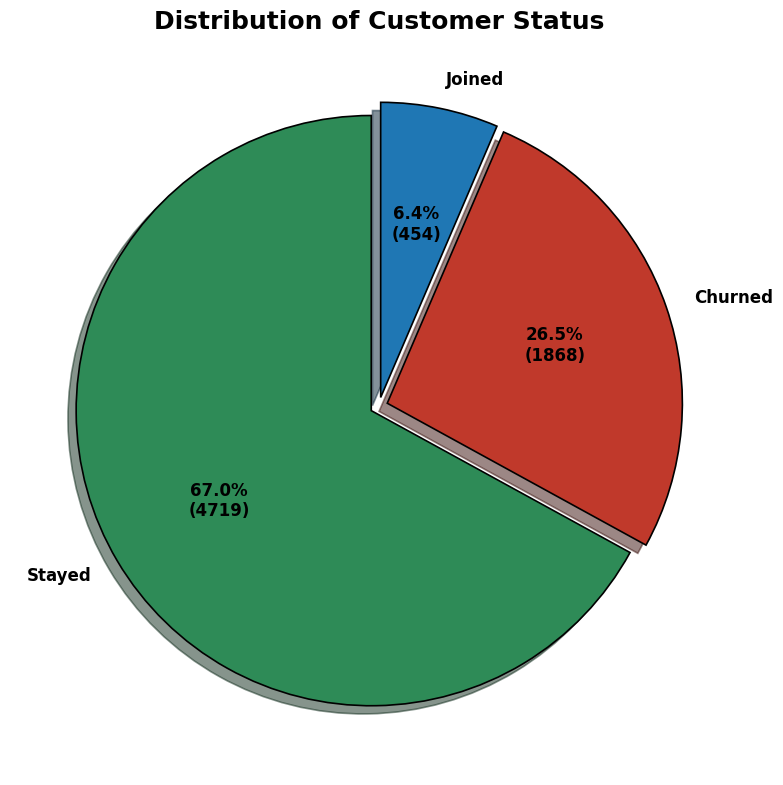

In [167]:
# Count Customer Status
status_counts = customer_churn["Customer Status"].value_counts()

# Colors
colors = ["#2E8B57", "#C0392B", "#1F77B4"]

# Plot Pie Chart
plt.figure(figsize=(8,8))

plt.pie(
    status_counts,
    labels=status_counts.index,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(status_counts)/100)})',
    startangle=90,
    explode=(0.03, 0.03, 0.03),
    shadow=True,
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 1.2
    },
    textprops={
        'fontsize': 12,
        'fontweight': 'bold'
    }
)

plt.title(
    "Distribution of Customer Status",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# **Contract Type vs Customer Status**

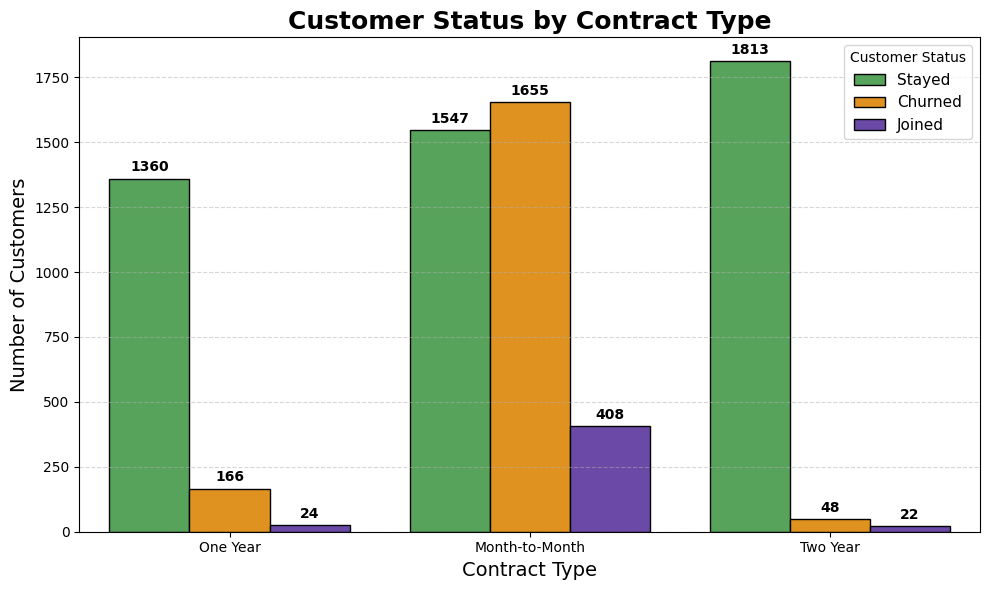

In [168]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=customer_churn,
    x="Contract",
    hue="Customer Status",
    palette={
        "Stayed": "#4CAF50",     # Green
        "Churned": "#FF9800",    # Orange
        "Joined": "#673AB7"      # Purple
    },
    edgecolor="black",
    linewidth=1
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=10,
        fontweight="bold",
        padding=3
    )

plt.title("Customer Status by Contract Type",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Contract Type", fontsize=14)
plt.ylabel("Number of Customers", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(title="Customer Status", fontsize=11)

plt.tight_layout()
plt.show()

# **Internet Service vs Customer Status**

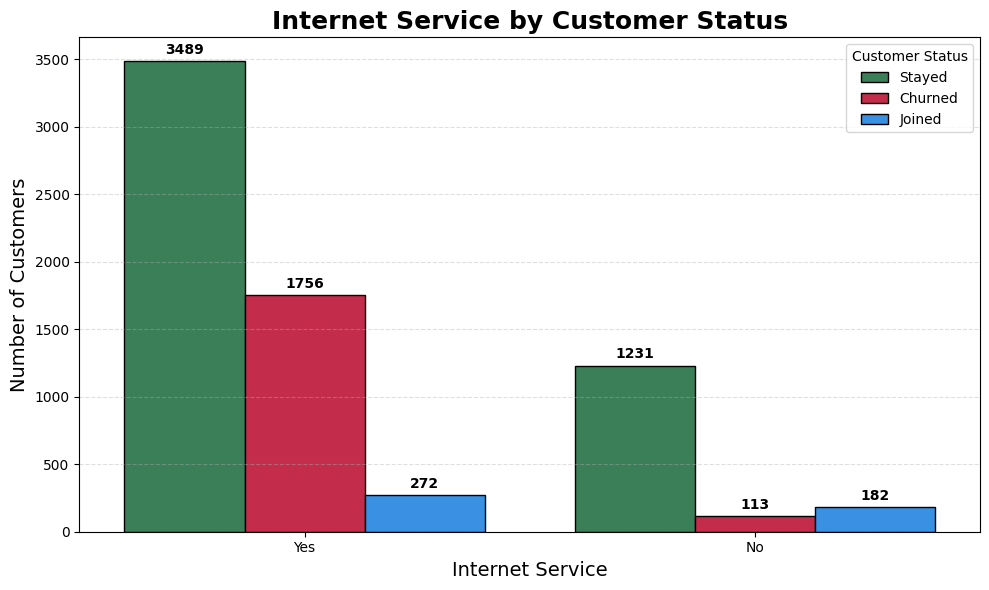

In [169]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=customer_churn,
    x="Internet Service",
    hue="Customer Status",
    palette={
        "Stayed": "#2E8B57",    # Green
        "Churned": "#DC143C",   # Red
        "Joined": "#1E90FF"     # Blue
    },
    edgecolor="black",
    linewidth=1
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        fontsize=10,
        fontweight='bold',
        padding=3
    )

plt.title("Internet Service by Customer Status",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Internet Service", fontsize=14)
plt.ylabel("Number of Customers", fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend(title="Customer Status")

plt.tight_layout()

plt.show()

# **Monthly Charges Distribution**

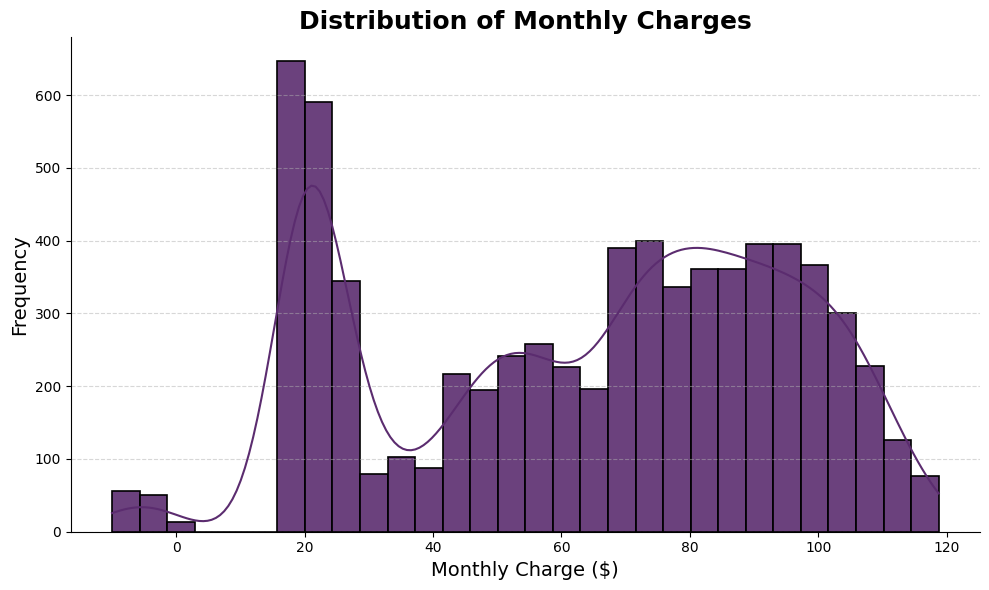

In [170]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=customer_churn,
    x="Monthly Charge",
    bins=30,
    kde=True,
    color="#5B2C6F",
    edgecolor="black",    # Black border
    linewidth=1.2,
    alpha=0.9
)

plt.title("Distribution of Monthly Charges",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Monthly Charge ($)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Remove top and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

# **Monthly Charges vs Customer Status**

/tmp/ipykernel_2220/2678205756.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




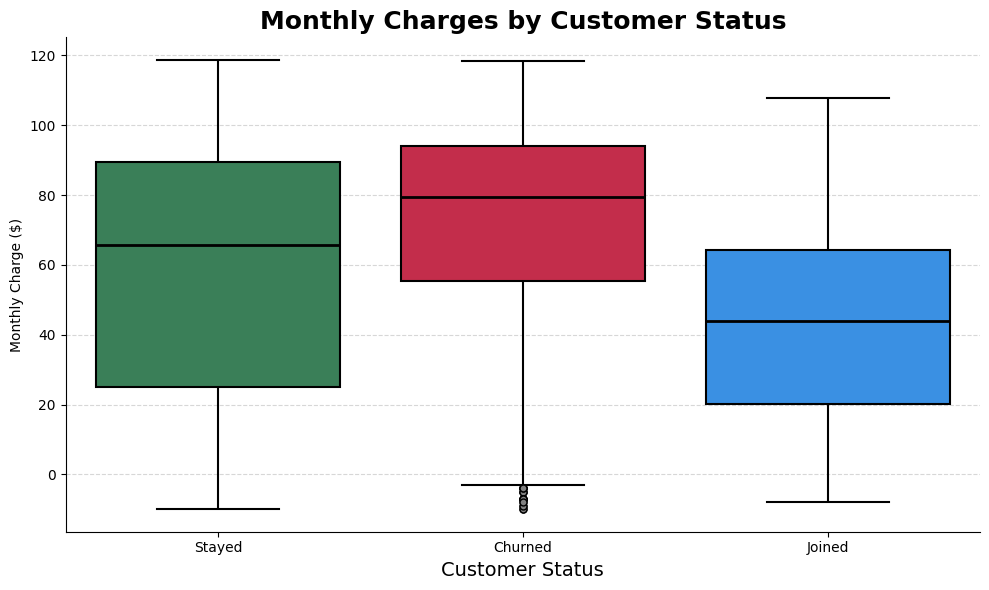

In [171]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=customer_churn,
    x="Customer Status",
    y="Monthly Charge",
    palette={
        "Stayed": "#2E8B57",    # Sea Green
        "Churned": "#DC143C",   # Crimson Red
        "Joined": "#1E90FF"     # Dodger Blue
    },
    linewidth=1.5,
    boxprops=dict(edgecolor="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker='o',
                    markerfacecolor='gray',
                    markeredgecolor='black',
                    markersize=5)
)

plt.title("Monthly Charges by Customer Status",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Customer Status", fontsize=14)
plt.ylabel("Monthly Charge ($)", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# Remove top and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# **Distribution of Customer Tenure**

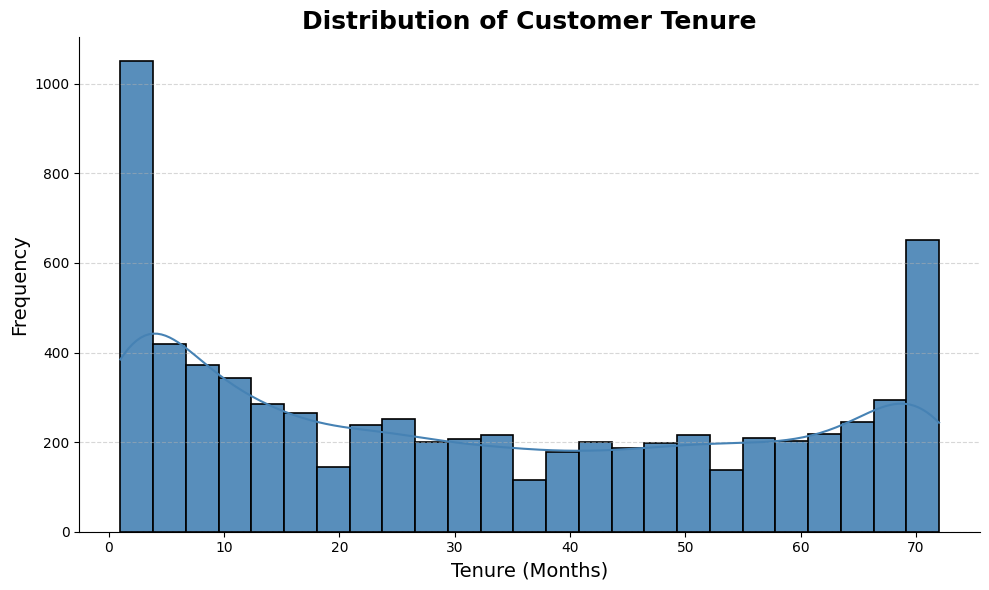

In [172]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=customer_churn,
    x="Tenure in Months",
    bins=25,
    kde=True,
    color="#4682B4",      # Deep blue
    edgecolor="black",    # Black border
    linewidth=1.2,
    alpha=0.9
)

plt.title("Distribution of Customer Tenure", fontsize=18, fontweight="bold")
plt.xlabel("Tenure (Months)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# Remove top and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# **Average Monthly Charge by Tenure**

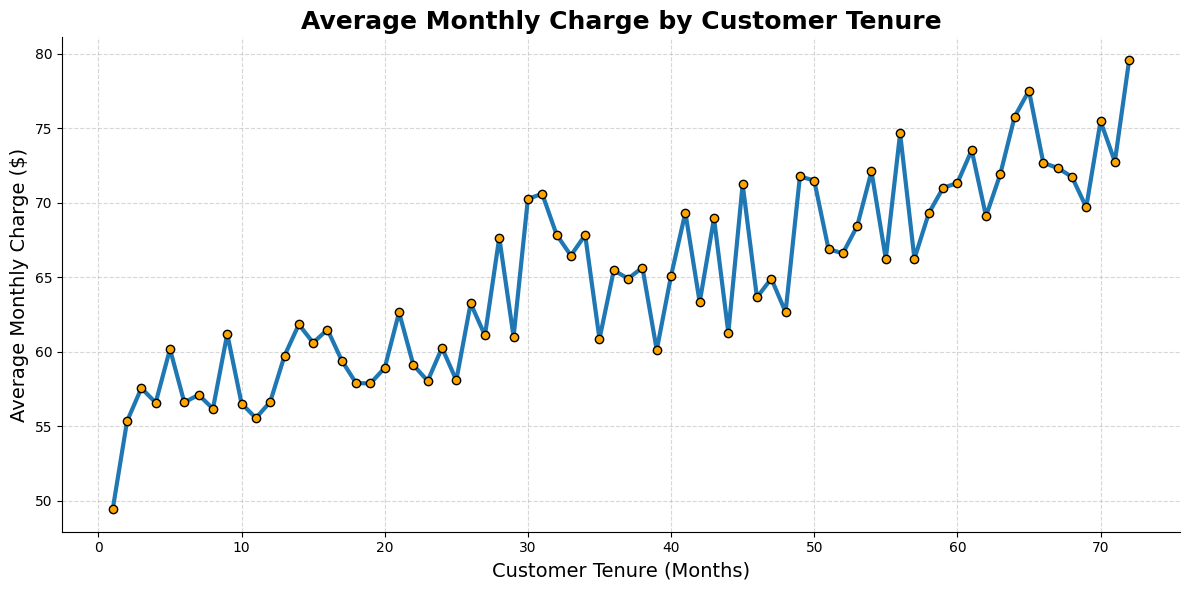

In [173]:
# Calculate average monthly charge by tenure
line_data = customer_churn.groupby("Tenure in Months")["Monthly Charge"].mean()

# Create figure
plt.figure(figsize=(12,6))

# Plot line
plt.plot(
    line_data.index,
    line_data.values,
    color="#1f77b4",
    linewidth=3,
    marker="o",
    markersize=6,
    markerfacecolor="orange",
    markeredgecolor="black"
)

# Titles
plt.title("Average Monthly Charge by Customer Tenure", fontsize=18, fontweight="bold")
plt.xlabel("Customer Tenure (Months)", fontsize=14)
plt.ylabel("Average Monthly Charge ($)", fontsize=14)

# Grid
plt.grid(True, linestyle="--", alpha=0.5)

# Remove extra borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Improve layout
plt.tight_layout()

plt.show()

# **Correlation Heatmap**

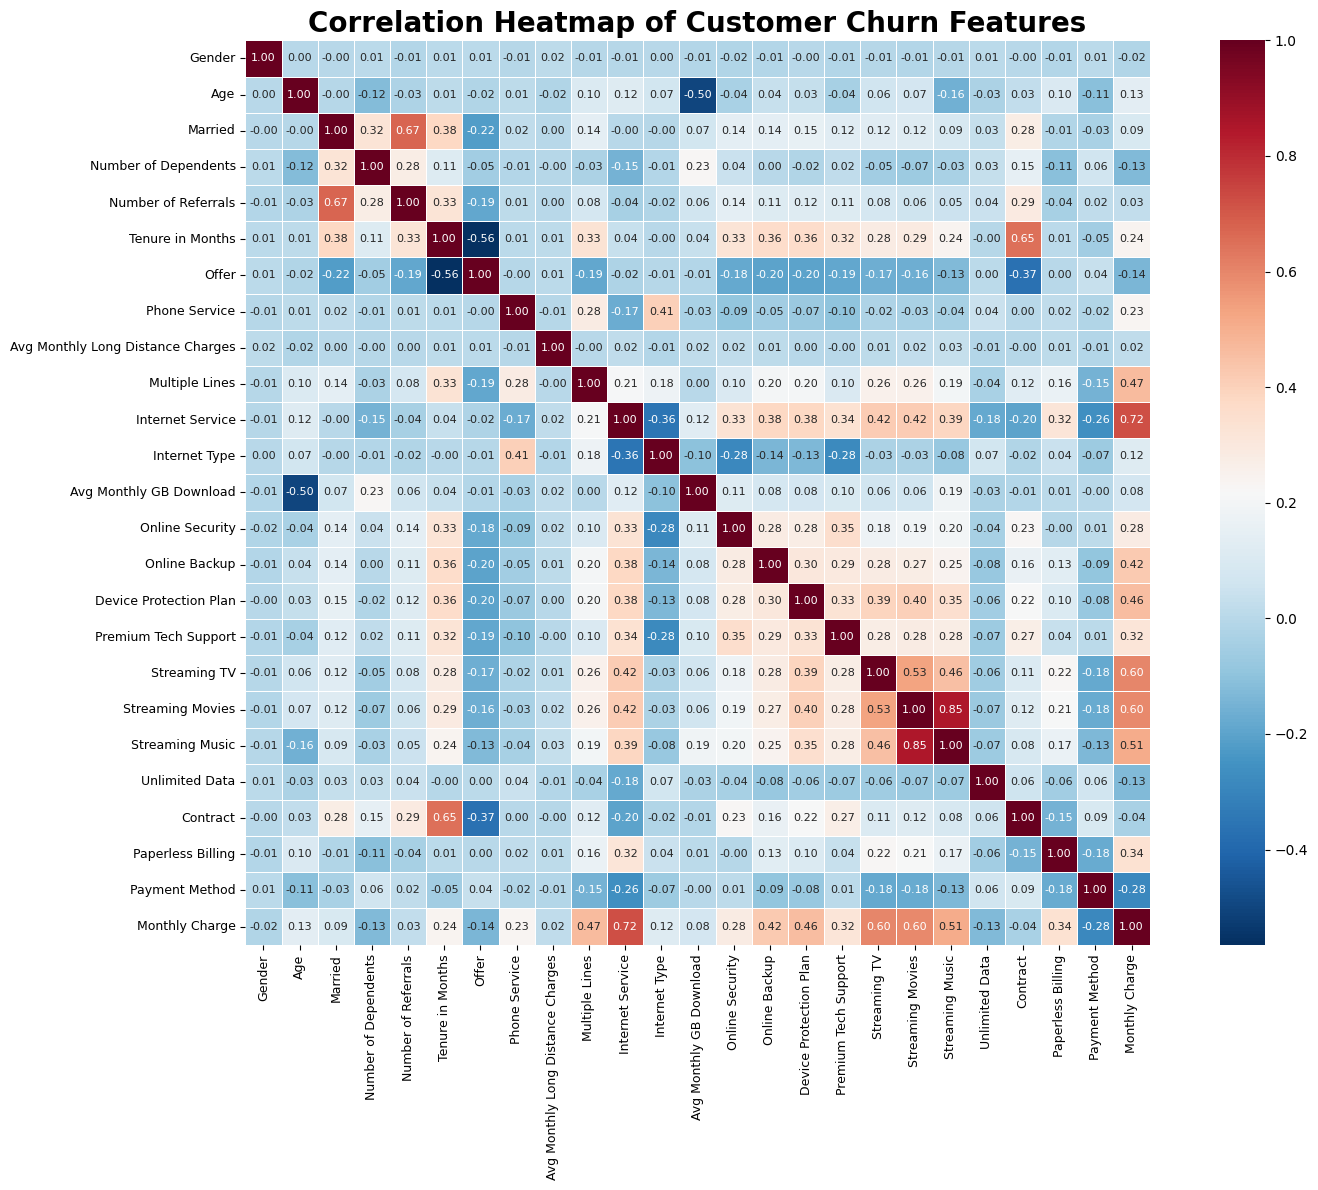

In [176]:
# =====================================================
# Correlation Heatmap
# =====================================================


# Calculate correlation matrix
correlation_matrix = X.corr()

# Create Heatmap
plt.figure(figsize=(16,12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={"size":8}
)

plt.title(
    "Correlation Heatmap of Customer Churn Features",
    fontsize=20,
    fontweight="bold"
)

plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# **Feature Selection**

In [177]:
# =====================================================
# Step 1: Feature Selection
# =====================================================

# Remove unnecessary columns
customer_churn = customer_churn.drop(columns=[
    "Customer ID",
    "Zip Code",
    "Latitude",
    "Longitude",
    "City",
    "Churn Category",
    "Churn Reason",
    "Total Charges",
    "Total Refunds",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Total Revenue"
])

# Create Feature Matrix (X) and Target Variable (y)
X = customer_churn.drop("Customer Status", axis=1)
y = customer_churn["Customer Status"]

# Display information
print("="*60)
print("Feature Selection Completed Successfully")
print("="*60)

print("\nFeature Matrix Shape (X):", X.shape)
print("Target Variable Shape (y):", y.shape)

print("\nTarget Variable Distribution:")
print(y.value_counts())

print("\nSelected Features:")
for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

Feature Selection Completed Successfully

Feature Matrix Shape (X): (7043, 25)
Target Variable Shape (y): (7043,)

Target Variable Distribution:
Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

Selected Features:
1. Gender
2. Age
3. Married
4. Number of Dependents
5. Number of Referrals
6. Tenure in Months
7. Offer
8. Phone Service
9. Avg Monthly Long Distance Charges
10. Multiple Lines
11. Internet Service
12. Internet Type
13. Avg Monthly GB Download
14. Online Security
15. Online Backup
16. Device Protection Plan
17. Premium Tech Support
18. Streaming TV
19. Streaming Movies
20. Streaming Music
21. Unlimited Data
22. Contract
23. Paperless Billing
24. Payment Method
25. Monthly Charge


# **Label Encoding**

In [178]:
# =====================================================
# Step 2: Label Encoding
# =====================================================


# Store LabelEncoders for each column
label_encoders = {}

# Select categorical columns
categorical_columns = X.select_dtypes(include=['object']).columns

# Encode categorical features
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Encode target variable
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# Display Results
print("="*60)
print("Label Encoding Completed Successfully")
print("="*60)

print("\nEncoded Feature Matrix (First 5 Rows)")
print(X.head())

print("\nTarget Variable Encoding")
for i, class_name in enumerate(target_encoder.classes_):
    print(f"{class_name} --> {i}")

print("\nFeature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Label Encoding Completed Successfully

Encoded Feature Matrix (First 5 Rows)
   Gender  Age  Married  Number of Dependents  Number of Referrals  \
0       0   37        1                     0                    2   
1       1   46        0                     0                    0   
2       1   50        0                     0                    0   
3       1   78        1                     0                    1   
4       0   75        1                     0                    3   

   Tenure in Months  Offer  Phone Service  Avg Monthly Long Distance Charges  \
0                 9      1              1                              42.39   
1                 9      1              1                              10.69   
2                 4      4              1                              33.65   
3                13      3              1                              27.82   
4                 3      1              1                               7.38   

   Multiple Lines  In

# **Train-Test Split**

In [179]:
# =====================================================
# Step 3: Train-Test Split
# =====================================================

from sklearn.model_selection import train_test_split

# Split the dataset into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes
print("="*60)
print("Train-Test Split Completed Successfully")
print("="*60)

print(f"Training Features (X_train): {X_train.shape}")
print(f"Testing Features (X_test):  {X_test.shape}")
print(f"Training Labels (y_train):  {y_train.shape}")
print(f"Testing Labels (y_test):    {y_test.shape}")

Train-Test Split Completed Successfully
Training Features (X_train): (5634, 25)
Testing Features (X_test):  (1409, 25)
Training Labels (y_train):  (5634,)
Testing Labels (y_test):    (1409,)


In [180]:
# =====================================================
# Step 4: Feature Scaling
# =====================================================

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

print("="*60)
print("Feature Scaling Completed Successfully")
print("="*60)

print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

Feature Scaling Completed Successfully
Scaled Training Shape : (5634, 25)
Scaled Testing Shape  : (1409, 25)


# **Classification Report of Logistic Regression**

In [181]:
# Create Logistic Regression model
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
log_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test_scaled)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log, average='weighted')
recall = recall_score(y_test, y_pred_log, average='weighted')
f1 = f1_score(y_test, y_pred_log, average='weighted')

# Print Evaluation Metrics
# Display Results
print("="*60)
print("Logistic Regression Performance")
print("="*60)

print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report Of Logistic Regression")
print(classification_report(y_test, y_pred_log))

Logistic Regression Performance

Accuracy: 0.8226

Classification Report Of Logistic Regression
              precision    recall  f1-score   support

           0       0.68      0.72      0.70       374
           1       0.63      0.60      0.62        91
           2       0.90      0.89      0.89       944

    accuracy                           0.82      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.83      0.82      0.82      1409



#**Confusion Matrix of Logistic Regression**

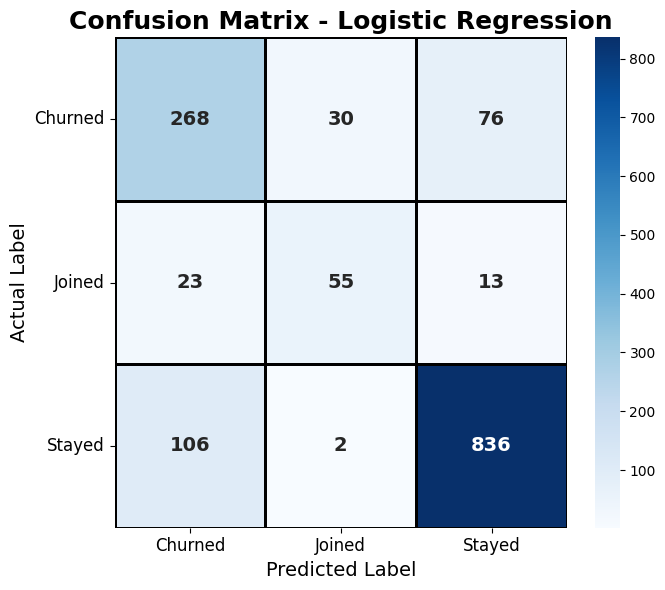

In [182]:
# =====================================================
# Confusion Matrix Visualization - Logistic Regression
# =====================================================

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    cbar=True,
    annot_kws={"size":14, "weight":"bold"}
)

plt.title("Confusion Matrix - Logistic Regression",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)

# Display original class names
plt.xticks(
    ticks=[0.5, 1.5, 2.5],
    labels=target_encoder.classes_,
    fontsize=12
)

plt.yticks(
    ticks=[0.5, 1.5, 2.5],
    labels=target_encoder.classes_,
    rotation=0,
    fontsize=12
)

plt.tight_layout()
plt.show()

# **ROC Curve - Logistic Regression**

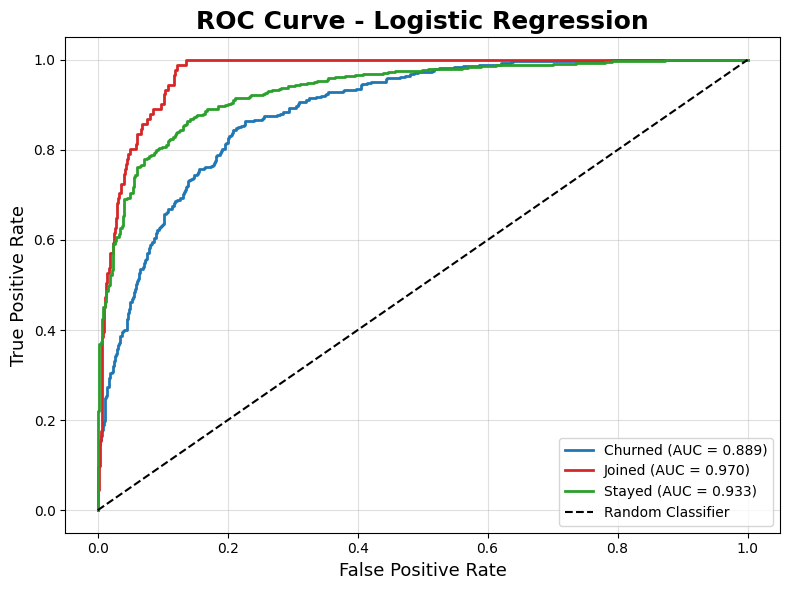

In [205]:
# =====================================================
# ROC Curve - Logistic Regression (Multi-Class)
# =====================================================

# Convert target to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score = log_model.predict_proba(X_test_scaled)

# Number of classes
n_classes = y_test_bin.shape[1]

# Plot
plt.figure(figsize=(8,6))

colors = ["#1f77b4", "#d62728", "#2ca02c"]

for i, color in zip(range(n_classes), colors):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{target_encoder.classes_[i]} (AUC = {roc_auc:.3f})"
    )

# Random Classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title(
    "ROC Curve - Logistic Regression",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)

plt.legend(loc="lower right")

plt.grid(alpha=0.4)

plt.tight_layout()

plt.show()

# **Classification Report of Decision Tree Model**

In [183]:
# =====================================================
# Decision Tree Model
# =====================================================

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred_dt)

# Display Results
print("="*60)
print("Decision Tree Performance")
print("="*60)

print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Performance

Accuracy: 0.7850

Classification Report
              precision    recall  f1-score   support

           0       0.59      0.65      0.61       374
           1       0.62      0.56      0.59        91
           2       0.89      0.86      0.88       944

    accuracy                           0.78      1409
   macro avg       0.70      0.69      0.69      1409
weighted avg       0.79      0.78      0.79      1409



# **Confusion Matrix of Decision Tree**

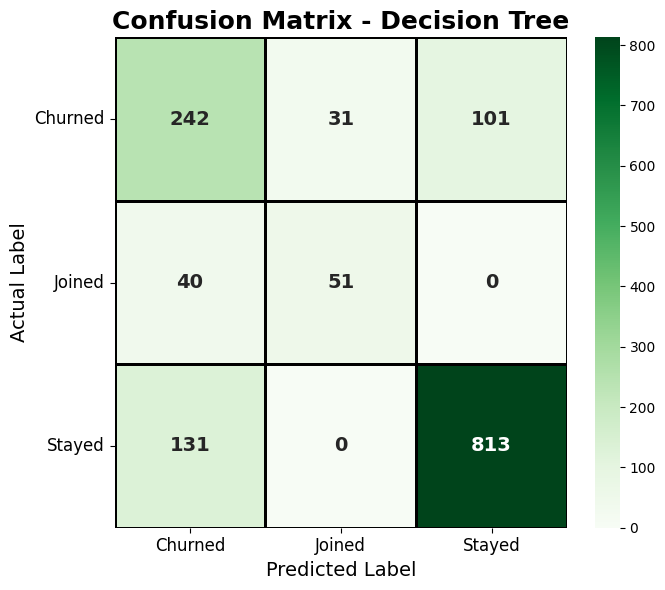

In [184]:
# =====================================================
# Confusion Matrix - Decision Tree
# =====================================================

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    linewidths=1,
    linecolor='black',
    cbar=True,
    annot_kws={"size":14, "weight":"bold"}
)

plt.title("Confusion Matrix - Decision Tree",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)

plt.xticks(
    ticks=[0.5, 1.5, 2.5],
    labels=target_encoder.classes_,
    fontsize=12
)

plt.yticks(
    ticks=[0.5, 1.5, 2.5],
    labels=target_encoder.classes_,
    rotation=0,
    fontsize=12
)

plt.tight_layout()
plt.show()

# **Decision Tree ROC Curve**

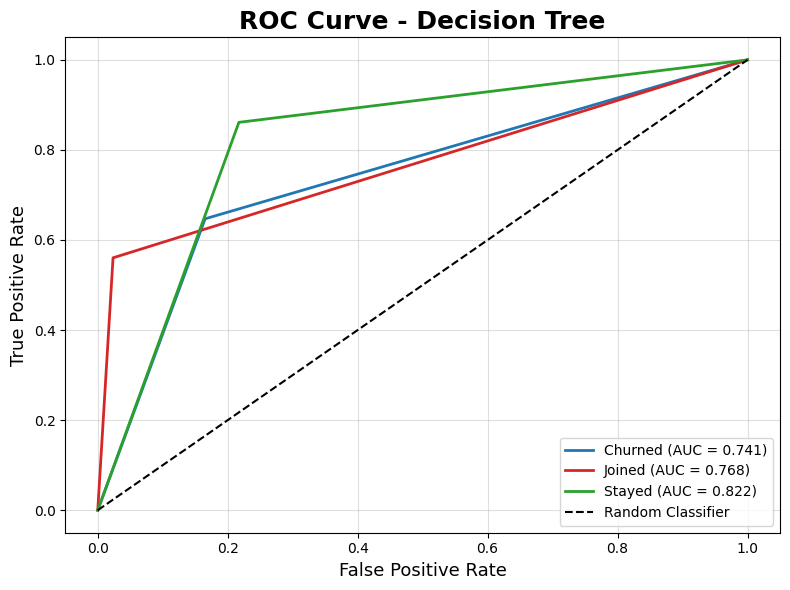

In [206]:
# =====================================================
# ROC Curve - Decision Tree (Multi-Class)
# =====================================================

# Convert target to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score = dt_model.predict_proba(X_test)

# Number of classes
n_classes = y_test_bin.shape[1]

# Plot ROC Curves
plt.figure(figsize=(8,6))

colors = ["#1f77b4", "#d62728", "#2ca02c"]

for i, color in zip(range(n_classes), colors):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{target_encoder.classes_[i]} (AUC = {roc_auc:.3f})"
    )

# Random Classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title(
    "ROC Curve - Decision Tree",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)

plt.legend(loc="lower right")

plt.grid(alpha=0.4)

plt.tight_layout()

plt.show()

# **Classification Report of Random Forest Model**

In [185]:
# =====================================================
# Random Forest Model
# =====================================================

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred_rf)

# Display Results
print("="*60)
print("Random Forest Performance")
print("="*60)

print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance

Accuracy: 0.8502

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.69      0.71       374
           1       0.79      0.66      0.72        91
           2       0.90      0.93      0.91       944

    accuracy                           0.85      1409
   macro avg       0.81      0.76      0.78      1409
weighted avg       0.85      0.85      0.85      1409



# **Confusion Matrix of Random Forest**

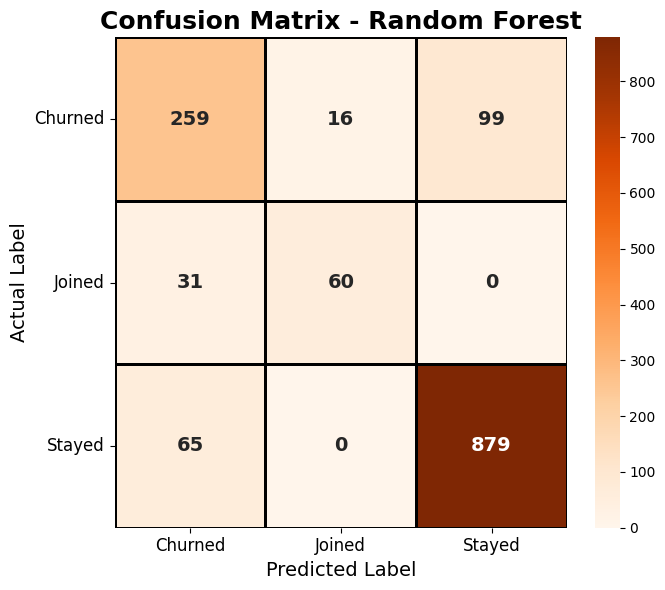

In [186]:
# =====================================================
# Confusion Matrix - Random Forest
# =====================================================

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    linewidths=1,
    linecolor="black",
    cbar=True,
    annot_kws={"size":14, "weight":"bold"}
)

plt.title("Confusion Matrix - Random Forest",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)

plt.xticks(
    ticks=[0.5, 1.5, 2.5],
    labels=target_encoder.classes_,
    fontsize=12
)

plt.yticks(
    ticks=[0.5, 1.5, 2.5],
    labels=target_encoder.classes_,
    rotation=0,
    fontsize=12
)

plt.tight_layout()
plt.show()

# **Random Forest ROC Curve**

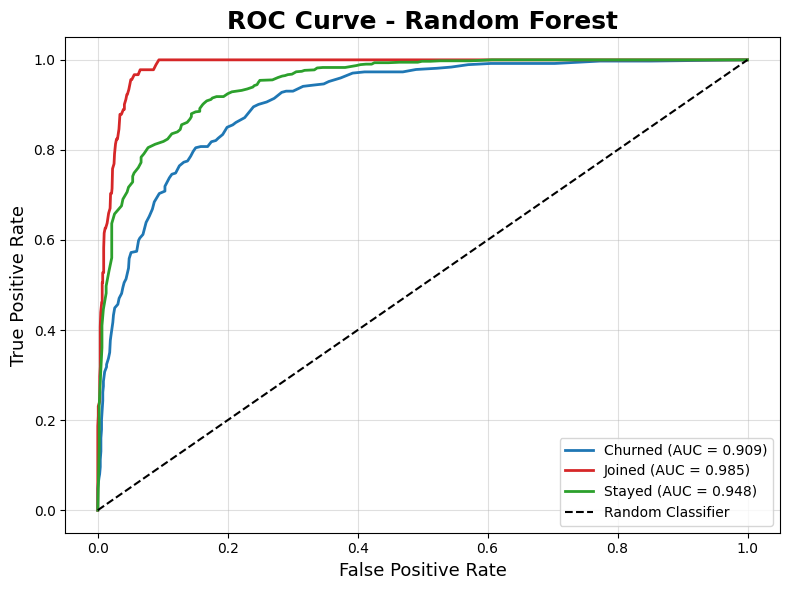

In [207]:
# =====================================================
# ROC Curve - Random Forest (Multi-Class)
# =====================================================
# Convert target to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score = rf_model.predict_proba(X_test)

# Number of classes
n_classes = y_test_bin.shape[1]

# Plot ROC Curves
plt.figure(figsize=(8,6))

colors = ["#1f77b4", "#d62728", "#2ca02c"]

for i, color in zip(range(n_classes), colors):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{target_encoder.classes_[i]} (AUC = {roc_auc:.3f})"
    )

# Random Classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title(
    "ROC Curve - Random Forest",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)

plt.legend(loc="lower right")

plt.grid(alpha=0.4)

plt.tight_layout()

plt.show()

# **Model Comparison Based on Accuracy**

Model Comparison Based on Accuracy
                 Model  Accuracy
0  Logistic Regression  0.822569
1        Decision Tree  0.784954
2        Random Forest  0.850248


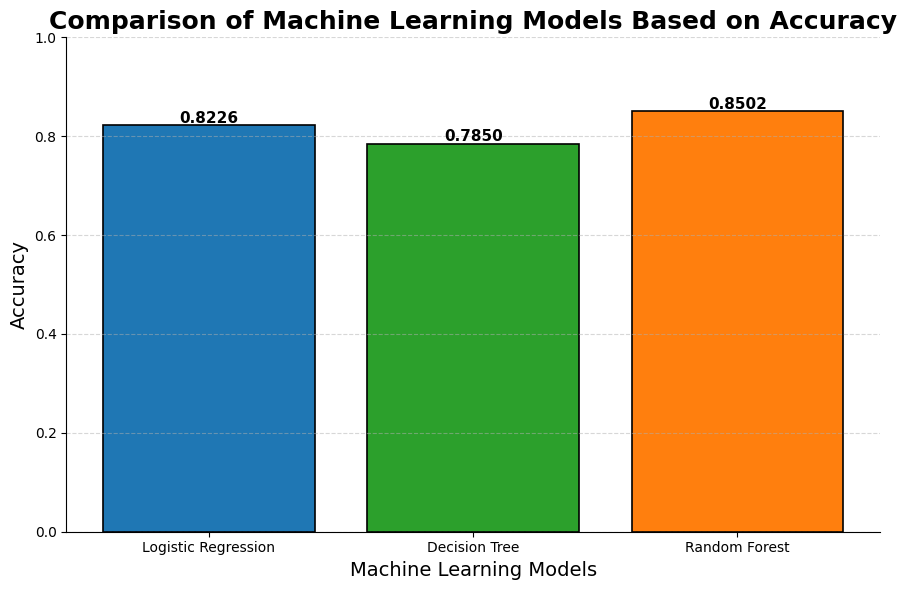

In [187]:
# =====================================================
# Model Comparison Based on Accuracy
# =====================================================

# Calculate Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Create Comparison Table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

# Display Table
print("="*60)
print("Model Comparison Based on Accuracy")
print("="*60)
print(model_comparison)

# Plot Accuracy Comparison
plt.figure(figsize=(9,6))

bars = plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"],
    color=["#1F77B4", "#2CA02C", "#FF7F0E"],
    edgecolor="black",
    linewidth=1.2
)

# Display Accuracy Values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Comparison of Machine Learning Models Based on Accuracy",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Machine Learning Models", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)

plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Remove unnecessary borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# **Customer Churn Analysis Dashboard**

/tmp/ipykernel_2220/810899164.py:92: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2220/810899164.py:145: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




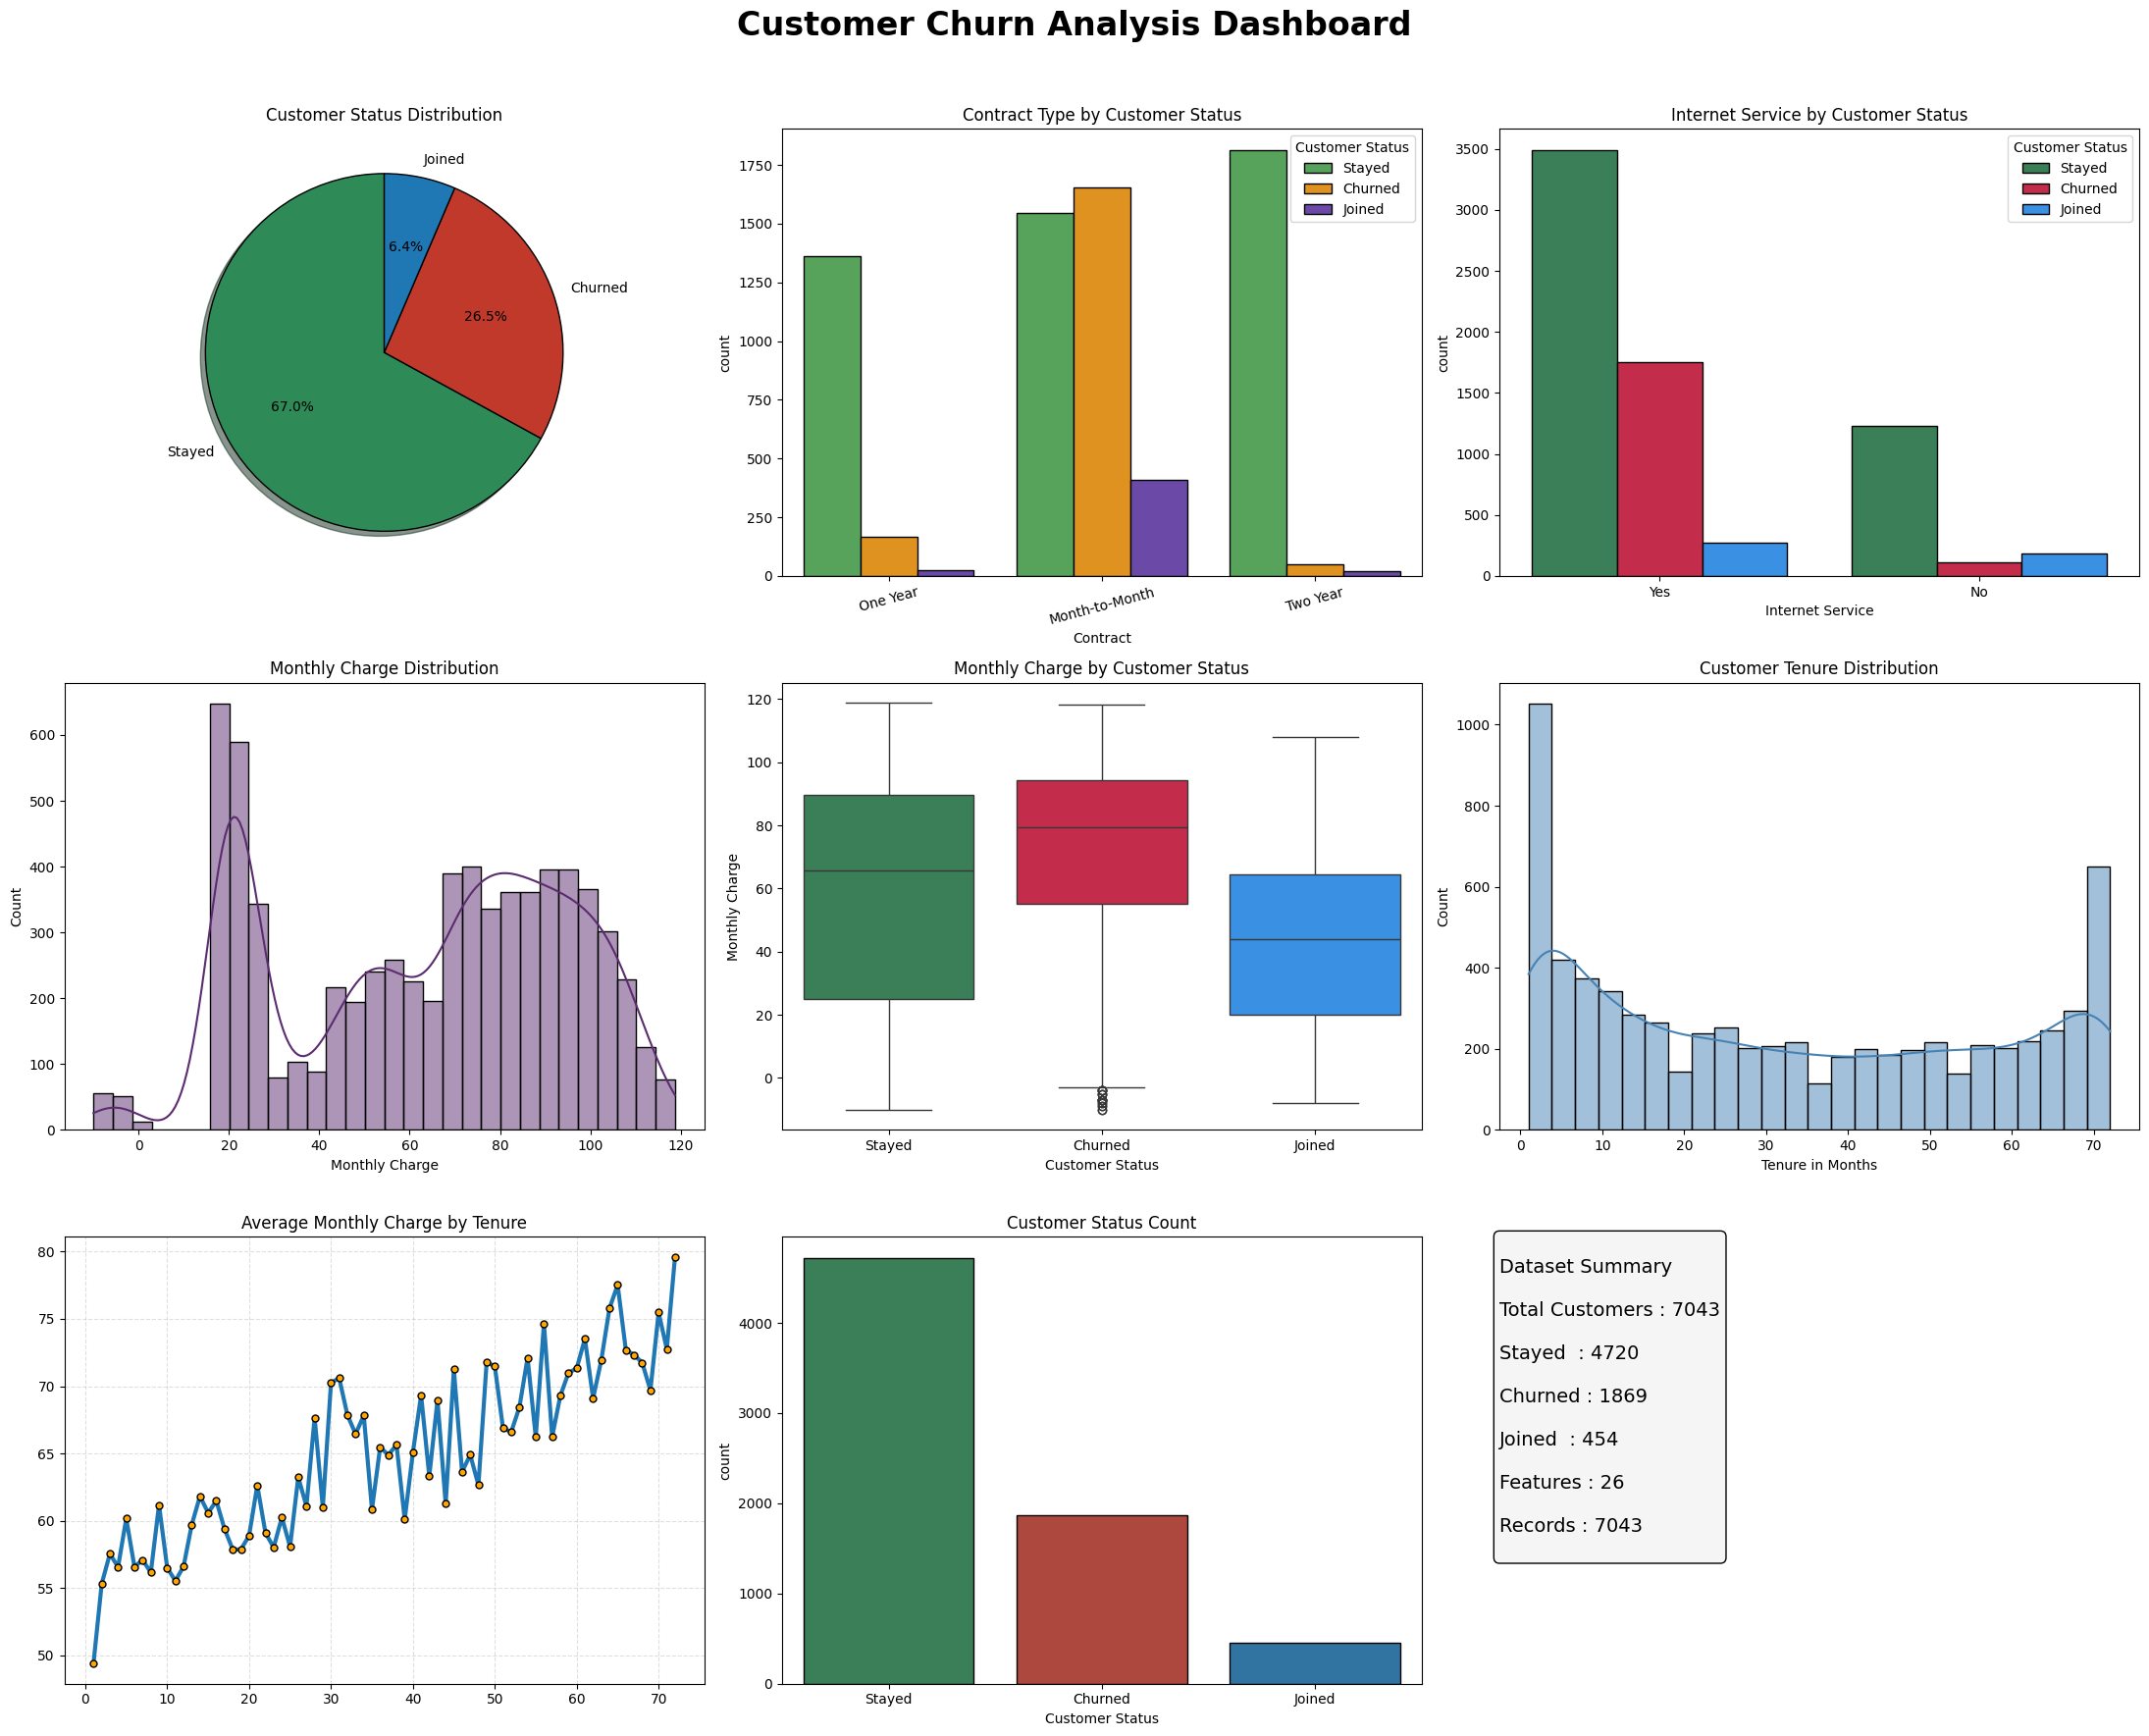

In [188]:
# ==========================================================
# Customer Churn Analysis Dashboard
# ==========================================================

fig, axes = plt.subplots(3, 3, figsize=(22, 18))

fig.suptitle(
    "Customer Churn Analysis Dashboard",
    fontsize=24,
    fontweight="bold"
)

# ==========================================================
# 1. Customer Status (Pie Chart)
# ==========================================================

status_counts = customer_churn["Customer Status"].value_counts()

axes[0,0].pie(
    status_counts,
    labels=status_counts.index,
    colors=["#2E8B57", "#C0392B", "#1F77B4"],
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
    wedgeprops={"edgecolor":"black"}
)

axes[0,0].set_title("Customer Status Distribution")

# ==========================================================
# 2. Contract Type
# ==========================================================

sns.countplot(
    data=customer_churn,
    x="Contract",
    hue="Customer Status",
    palette={
        "Stayed":"#4CAF50",
        "Churned":"#FF9800",
        "Joined":"#673AB7"
    },
    edgecolor="black",
    ax=axes[0,1]
)

axes[0,1].set_title("Contract Type by Customer Status")
axes[0,1].tick_params(axis='x', rotation=15)

# ==========================================================
# 3. Internet Service
# ==========================================================

sns.countplot(
    data=customer_churn,
    x="Internet Service",
    hue="Customer Status",
    palette={
        "Stayed":"#2E8B57",
        "Churned":"#DC143C",
        "Joined":"#1E90FF"
    },
    edgecolor="black",
    ax=axes[0,2]
)

axes[0,2].set_title("Internet Service by Customer Status")

# ==========================================================
# 4. Monthly Charge Distribution
# ==========================================================

sns.histplot(
    customer_churn["Monthly Charge"],
    bins=30,
    color="#5B2C6F",
    edgecolor="black",
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title("Monthly Charge Distribution")

# ==========================================================
# 5. Monthly Charge Boxplot
# ==========================================================

sns.boxplot(
    data=customer_churn,
    x="Customer Status",
    y="Monthly Charge",
    palette={
        "Stayed":"#2E8B57",
        "Churned":"#DC143C",
        "Joined":"#1E90FF"
    },
    ax=axes[1,1]
)

axes[1,1].set_title("Monthly Charge by Customer Status")

# ==========================================================
# 6. Tenure Distribution
# ==========================================================

sns.histplot(
    customer_churn["Tenure in Months"],
    bins=25,
    color="#4682B4",
    edgecolor="black",
    kde=True,
    ax=axes[1,2]
)

axes[1,2].set_title("Customer Tenure Distribution")

# ==========================================================
# 7. Line Chart
# ==========================================================

line_data = customer_churn.groupby("Tenure in Months")["Monthly Charge"].mean()

axes[2,0].plot(
    line_data.index,
    line_data.values,
    color="#1f77b4",
    linewidth=3,
    marker="o",
    markersize=5,
    markerfacecolor="orange",
    markeredgecolor="black"
)

axes[2,0].set_title("Average Monthly Charge by Tenure")
axes[2,0].grid(True, linestyle="--", alpha=0.4)

# ==========================================================
# 8. Customer Status Count
# ==========================================================

sns.countplot(
    data=customer_churn,
    x="Customer Status",
    palette={
        "Stayed":"#2E8B57",
        "Churned":"#C0392B",
        "Joined":"#1F77B4"
    },
    edgecolor="black",
    ax=axes[2,1]
)

axes[2,1].set_title("Customer Status Count")

# ==========================================================
# 9. Dashboard Summary
# ==========================================================

axes[2,2].axis("off")

summary = f"""
Dataset Summary

Total Customers : {len(customer_churn)}

Stayed  : {(customer_churn['Customer Status']=='Stayed').sum()}

Churned : {(customer_churn['Customer Status']=='Churned').sum()}

Joined  : {(customer_churn['Customer Status']=='Joined').sum()}

Features : {customer_churn.shape[1]}

Records : {customer_churn.shape[0]}
"""

axes[2,2].text(
    0,
    1,
    summary,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(facecolor="#F5F5F5",
              edgecolor="black",
              boxstyle="round")
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

# **Customer Churn Prediction System**

In [198]:
# ==========================================================
# Customer Churn Prediction System - User Interface
# ==========================================================

# --------------------------
# Categorical Features
# --------------------------

gender = widgets.Dropdown(
    options=['Female','Male'],
    description='Gender:'
)

married = widgets.Dropdown(
    options=['No','Yes'],
    description='Married:'
)

offer = widgets.Dropdown(
    options=['Offer A','Offer B','Offer C','Offer D','Offer E'],
    description='Offer:'
)

phone_service = widgets.Dropdown(
    options=['No','Yes'],
    description='Phone Service:'
)

multiple_lines = widgets.Dropdown(
    options=['No','Yes'],
    description='Multiple Lines:'
)

internet_service = widgets.Dropdown(
    options=['No','Yes'],
    description='Internet Service:'
)

internet_type = widgets.Dropdown(
    options=['Cable','DSL','Fiber Optic'],
    description='Internet Type:'
)

online_security = widgets.Dropdown(
    options=['No','Yes'],
    description='Online Security:'
)

online_backup = widgets.Dropdown(
    options=['No','Yes'],
    description='Online Backup:'
)

device_plan = widgets.Dropdown(
    options=['No','Yes'],
    description='Device Protection:'
)

tech_support = widgets.Dropdown(
    options=['No','Yes'],
    description='Premium Support:'
)

stream_tv = widgets.Dropdown(
    options=['No','Yes'],
    description='Streaming TV:'
)

stream_movie = widgets.Dropdown(
    options=['No','Yes'],
    description='Streaming Movies:'
)

stream_music = widgets.Dropdown(
    options=['No','Yes'],
    description='Streaming Music:'
)

unlimited = widgets.Dropdown(
    options=['No','Yes'],
    description='Unlimited Data:'
)

contract = widgets.Dropdown(
    options=['Month-to-Month','One Year','Two Year'],
    description='Contract:'
)

paperless = widgets.Dropdown(
    options=['No','Yes'],
    description='Paperless Billing:'
)

payment = widgets.Dropdown(
    options=['Bank Withdrawal','Credit Card','Mailed Check'],
    description='Payment Method:'
)

# --------------------------
# Numerical Features
# --------------------------

age = widgets.IntText(description='Age:')

dependents = widgets.IntText(description='Dependents:')

referrals = widgets.IntText(description='Referrals:')

tenure = widgets.IntText(description='Tenure:')

long_distance = widgets.FloatText(description='Long Distance:')

gb_download = widgets.FloatText(description='GB Download:')

monthly_charge = widgets.FloatText(description='Monthly Charge:')

# Predict Button

predict_btn = widgets.Button(
    description='Predict Customer',
    button_style='success'
)

# Display

title = widgets.HTML(
    "<h2 style='color:blue'>Customer Churn Prediction System</h2>"
)

display(title)

display(gender)
display(age)
display(married)
display(dependents)
display(referrals)
display(tenure)
display(offer)
display(phone_service)
display(long_distance)
display(multiple_lines)
display(internet_service)
display(internet_type)
display(gb_download)
display(online_security)
display(online_backup)
display(device_plan)
display(tech_support)
display(stream_tv)
display(stream_movie)
display(stream_music)
display(unlimited)
display(contract)
display(paperless)
display(payment)
display(monthly_charge)

display(predict_btn)
# ==========================================================
# Customer Churn Prediction Logic
# ==========================================================

from IPython.display import clear_output

output = widgets.Output()

display(output)

def predict_customer(b):

    with output:

        clear_output()

        # -----------------------------
        # Collect User Input
        # -----------------------------

        customer = {

            "Gender": gender.value,
            "Age": age.value,
            "Married": married.value,
            "Number of Dependents": dependents.value,
            "Number of Referrals": referrals.value,
            "Tenure in Months": tenure.value,
            "Offer": offer.value,
            "Phone Service": phone_service.value,
            "Avg Monthly Long Distance Charges": long_distance.value,
            "Multiple Lines": multiple_lines.value,
            "Internet Service": internet_service.value,
            "Internet Type": internet_type.value,
            "Avg Monthly GB Download": gb_download.value,
            "Online Security": online_security.value,
            "Online Backup": online_backup.value,
            "Device Protection Plan": device_plan.value,
            "Premium Tech Support": tech_support.value,
            "Streaming TV": stream_tv.value,
            "Streaming Movies": stream_movie.value,
            "Streaming Music": stream_music.value,
            "Unlimited Data": unlimited.value,
            "Contract": contract.value,
            "Paperless Billing": paperless.value,
            "Payment Method": payment.value,
            "Monthly Charge": monthly_charge.value

        }

        customer_df = pd.DataFrame([customer])

        # -----------------------------
        # Encode Categorical Features
        # -----------------------------

        for col in label_encoders:
            customer_df[col] = label_encoders[col].transform(customer_df[col])

        # -----------------------------
        # Prediction
        # -----------------------------

        prediction = rf_model.predict(customer_df)

        prediction_label = target_encoder.inverse_transform(prediction)[0]

        probability = rf_model.predict_proba(customer_df)

        confidence = probability.max() * 100

        # -----------------------------
        # Display Result
        # -----------------------------

        print("="*60)
        print(" CUSTOMER CHURN PREDICTION RESULT ")
        print("="*60)

        print(f"\nPrediction : {prediction_label}")

        print(f"Confidence : {confidence:.2f}%")

        print("\nRecommended Action")

        if prediction_label == "Stayed":

            print("✓ Customer is likely to stay.")
            print("✓ Continue current services.")
            print("✓ Reward loyal customers.")
            print("✓ Maintain customer engagement.")

        elif prediction_label == "Churned":

            print("⚠ Customer is likely to churn.")
            print("✓ Offer loyalty discount.")
            print("✓ Upgrade Internet Plan.")
            print("✓ Provide Premium Tech Support.")
            print("✓ Recommend One-Year Contract.")
            print("✓ Contact customer immediately.")

        else:

            print("✓ Customer recently joined.")
            print("✓ Welcome package.")
            print("✓ Offer promotional discounts.")
            print("✓ Encourage loyalty program.")

        print("="*60)

# Connect Button
predict_btn.on_click(predict_customer)

HTML(value="<h2 style='color:blue'>Customer Churn Prediction System</h2>")

Dropdown(description='Gender:', options=('Female', 'Male'), value='Female')

IntText(value=0, description='Age:')

Dropdown(description='Married:', options=('No', 'Yes'), value='No')

IntText(value=0, description='Dependents:')

...

Dropdown(description='Paperless Billing:', options=('No', 'Yes'), value='No')

Dropdown(description='Payment Method:', options=('Bank Withdrawal', 'Credit Card', 'Mailed Check'), value='Ban…

FloatText(value=0.0, description='Monthly Charge:')

Button(button_style='success', description='Predict Customer', style=ButtonStyle())

Output()